## Take the outputs of a refinement and interrogate the results

In [2]:
# Imports used for this tutorial
import numpy as np
import os
from MDMC.control import Control
from MDMC.MD import Atom, Dispersion, LennardJones, Simulation, Universe

# Build universe with density 0.0176 atoms per AA^-3
density = 0.0176
universe = Universe(dimensions=23.0668)
Ar = Atom('Ar', charge=0., mass=36.0)
# Calculating number of Ar atoms needed to obtain density
n_ar_atoms = int(density * np.product(universe.dimensions))
universe.fill(Ar, num_struc_units=(n_ar_atoms))

Ar_dispersion = Dispersion(universe,
                           (Ar.atom_type, Ar.atom_type),
                           cutoff=8.,
                           function=LennardJones(epsilon=1.0243, sigma=3.36))

simulation = Simulation(universe,
                        engine="lammps",
                        time_step=10.18893,
                        temperature=120.,
                        traj_step=15)
simulation.minimize(n_steps=5000)
simulation.run(n_steps=10000, equilibration=True)

exp_datasets = [{'file_name':'../../doc/tutorials/data/Well_s_q_omega_Ar_data.xml',
                 'type':'SQw',
                 'reader':'xml_SQw',
                 'weight':1.,
                 'auto_scale':True,
                 'resolution':7500}]

fit_parameters = universe.parameters
fit_parameters['sigma'].constraints = [2.8,3.8]
fit_parameters['epsilon'].constraints = [0.6, 1.4]

control = Control(simulation=simulation,
                  exp_datasets=exp_datasets,
                  fit_parameters=fit_parameters,
                  minimizer_type="GPO",
                  reset_config=True,
                  MD_steps=2000, 
                  equilibration_steps=2000)
control.refine(n_steps=25)

# This cell takes around 2 minutes to run

Universe created with:
  Dimensions       [23.07, 23.07, 23.07]
  Force field                       None
  Number of atoms                      0

LAMMPS (29 Sep 2021 - Update 3)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
LAMMPS output is captured by PyLammps wrapper
LAMMPS (29 Sep 2021 - Update 3)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
LAMMPS output is captured by PyLammps wrapper
Total wall time: 0:00:00
Simulation created with lammps engine and settings:
  temperature  120.0

Control created with:
- Attributes                              -
  Minimizer                             GPO
  FoM type               ChiSquaredExpError
  Number of observables                   1
  Number of parameters                    2

Step         FoM Change state  Pred coords     Pred FoM epsilon (#5)   sigma (#6)
   0        1140     Accepted

### Look at the liklihood of the parameter values across the range of possible parameter values

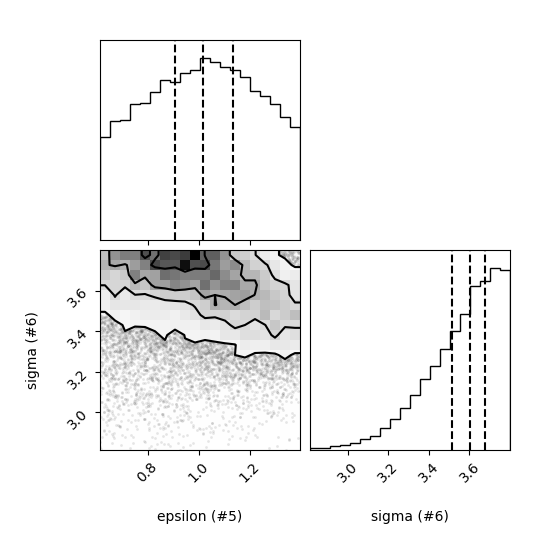

In [28]:
control.plot_results();

In [8]:

%matplotlib widget
from MDMC.trajectory_analysis.observables.obs_factory import ObservableFactory
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

obs_pair_lmp = control.observable_pairs[0]
result_lmp = obs_pair_lmp.MD_obs.SQw / obs_pair_lmp.rescale_factor

SQw = obs_pair_lmp.exp_obs.SQw
SQw_err = obs_pair_lmp.exp_obs.SQw_err
Q = obs_pair_lmp.exp_obs.Q
E = obs_pair_lmp.exp_obs.E


### Below is plotting code to look at the S(Q,w) as a function of Q. This will be a TODO: Put code into `control` or `plot_results`

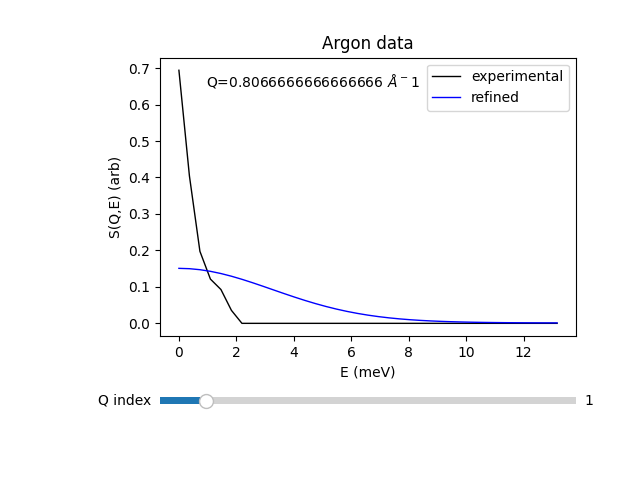

In [26]:
fig, ax = plt.subplots()
exp_line, = ax.plot(E, SQw[0,0], linewidth=1, color='black')
sim_line, = ax.plot(E, result_lmp[0,1,:], linewidth=1, color='blue')
ax.legend(labels=['experimental', 'refined'])
ax.set_xlabel('E (meV)')
ax.set_ylabel('S(Q,E) (arb)')
ax.set_title('Argon data')

fig.subplots_adjust(left=0.25, bottom=0.3)
Q_slider_ax  = fig.add_axes([0.25, 0.15, 0.65, 0.03], facecolor='lightgoldenrodyellow')
Q_slider = Slider(Q_slider_ax, 'Q index', 0, len(Q)-1, valinit=1, valstep=1)
Q_label=plt.text(1,1.7,f'Q={Q[1]} $\AA^{-1}$')


def Q_on_changed(val):
    exp_line.set_ydata(SQw[0,val])
    sim_line.set_ydata(result_lmp[0,val])
    Q_label.set_text(f'Q={Q[val]} $\AA^{-1}$')
    fig.canvas.draw_idle()
    ax.set_ylim(0,max(np.max(SQw[0,val])+0.1,1e-5))

Q_slider.on_changed(Q_on_changed)
plt.show()

### We can also look at PDF's. This comes from the water trajectory

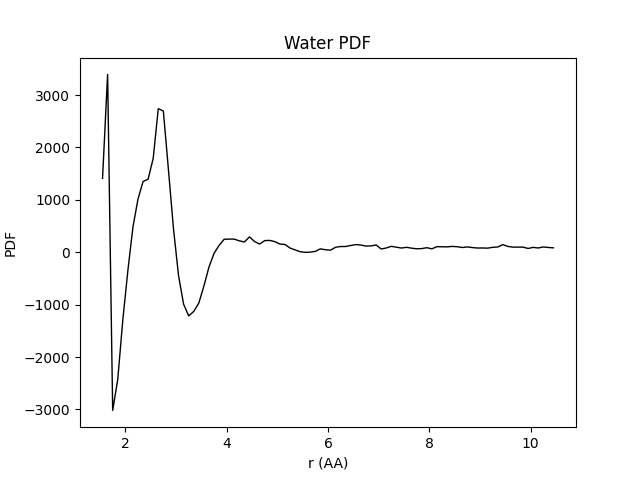

In [39]:
obs=ObservableFactory.create_observable('PDF')
obs.read_from_file(reader='netCDFPDF', file_name='../../tests/test_data/calculated_observables/nMOLDYN_PDF_water.nc')

fig, ax = plt.subplots()
exp_line, = ax.plot(obs.r[15:], obs.PDF[15:], linewidth=1, color='black')
ax.set_xlabel('r (AA)')
ax.set_ylabel('PDF')
ax.set_title('Water PDF')
plt.show()
# exp_line, = ax.plot(obs.r, obs.PDF, linewidth=1, color='black')